In [2]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numba
from numba import njit
import random


In [36]:
T_periode = 50.0
choices = [T_periode, T_periode / 2, 1.5 * T_periode]

def generate_batch_boundaries(t_max, seed=None):
    """
    Generate variable batch boundaries up to max time using random durations.
    
    Returns:
        - boundaries: list of batch end times.
        - types: list of 0/1 batch types (0 for water, 1 for phosphate).
    """
    if seed is not None:
        random.seed(seed)
    
    boundaries = []
    types = []
    t = 0.0
    batch_type = 0  # Start with water
    
    while t <= t_max:
        duration = random.choice(choices)
        t += duration
        boundaries.append(t)
        types.append(batch_type)
        batch_type = 1 - batch_type  # alternate
    
    return np.array(boundaries), np.array(types)

def get_density(t, seed=None):
    """
    Returns the density (as a NumPy array) based on randomized batch durations.
    
    Parameters:
        t (np.ndarray or float): Time(s) in seconds.
        seed (int, optional): Random seed for reproducibility.
        
    Returns:
        np.ndarray: Density values (1.0 or 1.6), same shape as t.
    """
    t = np.asarray(t, dtype=np.float32)
    t_flat = t.flatten()
    t_max = np.max(t_flat)
    
    boundaries, types = generate_batch_boundaries(t_max, seed)
    
    # np.searchsorted gives the index of the first boundary greater than each t
    indices = np.searchsorted(boundaries, t_flat, side='right')
    selected_types = types[indices]
    
    density = np.where(selected_types == 0, 1.0, 1.6)
    return density.reshape(t.shape)


# Load data from CSV files
mes_time = np.arange(0, 3601, 180)  # Time in seconds
rho_in_mes = get_initial_data(
    mes_time,
    Val1=1.0,  # Density for water
    Val2=1.6   # Density for phosphate
)
mu_in_mes = get_initial_data(
    mes_time,
    Val1=0.001,  # Viscosity for water
    Val2=0.016   # Viscosity for phosphate
)

Q_out_mes = 1.2* np.ones_like(mes_time)  # Flow rate in m^3/s
P_out_mes = 1000 * np.ones_like(mes_time) 


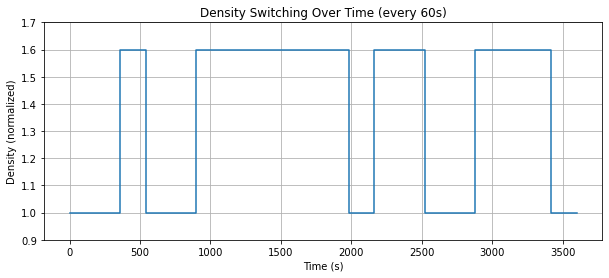

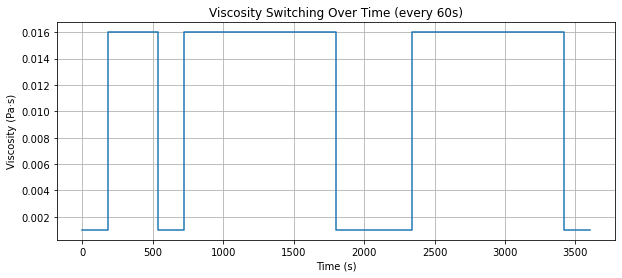

In [37]:
# Generate time values from 0 to 600 seconds
t_values = mes_time

# Plot
plt.figure(figsize=(10, 4))
plt.plot(t_values, rho_in_mes, drawstyle='steps-post')
plt.xlabel("Time (s)")
plt.ylabel("Density (normalized)")
plt.title("Density Switching Over Time (every 60s)")
plt.grid(True)
plt.ylim(0.9, 1.7)
plt.show()

# Generate time values from 0 to 600 seconds
t_values = mes_time

# Plot
plt.figure(figsize=(10, 4))
plt.plot(t_values,mu_in_mes.copy(), drawstyle='steps-post')
plt.xlabel("Time (s)")
plt.ylabel("Viscosity (Pa·s)")
plt.title("Viscosity Switching Over Time (every 60s)")
plt.grid(True)
plt.show()

In [38]:
########################################################### The Solver ###########################################################
L = 1000  
D = 0.855   
A = np.pi * (D**2) / 4  
N = 500    
dx = L / N  
eps = .0213e-3
mesure_time=mes_time.copy()
x = np.linspace(0, L, N)  

theta = np.zeros(N)

U_in = Q_out_mes[0]/(A)
# print(U_in)


Q_in = U_in * A  




rho_in = 1 * np.ones(N)    
mu_in = .001 * np.ones(N)

a = 1.25
Tf = mesure_time[0]+3600
dt = 2
g = 9.81  
lam = 0.1



def m_vector(rho,A,dx):
    m_vec = A*dx*rho
    return m_vec

@njit
def I_vector(v,rho,A,dx):
    I_vec = np.zeros_like(rho)
    for i in range(len(I_vec)):
        I_vec[i] = v*A*dx*rho[i]
    return I_vec

m_vec_0 = m_vector(rho_in, A, dx)
I_vec_0 = I_vector(U_in, rho_in, A, dx)

@njit
def Reynold(rho, u, D, mu):
    Re = np.zeros(N)
    for i in range(N):
        Re[i] = rho[i]*u*D/mu[i]
    return Re

@njit
def compute_P(P, A , g,theta, U_old, U_new, U, m_i, pressure_drop, dt,P_out):
    P_new = np.zeros_like(P)
    P_new[-1] = P_out
    for i in range(N-2, -1, -1):
        P_new[i] = P_new[i+1] + m_i[i]/A * (np.abs(g)*np.sin(theta[i]) + (U_new-U)/dt) + pressure_drop[i]
        
    if U < 1 or U_new <1 or U_old <1:
        P_new[0] = 0
    return P_new



#@njit
def Friction(a,Re,D,eps):
    den = np.zeros(N)
    fr = np.zeros(N)
    for i in range(N):
        den[i] = np.log(eps/(3.7*D)+5.74/(Re[i]**0.9)) ** 2
        fr[i] = a/den[i]
                              
    return fr

@njit
def sigmoid(fa,fb,ta,tb,lam,t):
    return fa + (fb-fa) / (1 + np.exp((0.5 * (ta+tb)-t)/(lam*dt)))



Re_s = Reynold(rho_in, U_in, D, mu_in)
f_D = Friction(a, Re_s, D, eps)
 
pressure_drop = dx * f_D * rho_in * U_in**2 / (2 * D)
@njit
def compute_dt(U, mu, dx, Cfl):
    if U<1e-3:
        dt_adv = 10
    else:
        dt_adv = Cfl * dx / abs(U)
    dt_diff = Cfl * dx**2 / np.max(mu)
    return min(200, dt_adv)#, dt_diff)

P_0 = np.zeros(N)  
U = U_in  

P_0[-1] = P_out_mes[0]



def solver():

    dt = 10
    
    m_vec = m_vec_0.copy()
    I_vec = I_vec_0.copy()
    mu = mu_in.copy()
    P = P_0.copy()
    rho = rho_in.copy()
    #q = q.copy()
    U = U_in
    Q = Q_in

    PHI = 0
    
    
    m_vec_new, I_vec_new, mu_new, rho_new, P_new = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    U_new = U
    Q_new = Q
    U_old = U
    time = mesure_time[0]
    U_data , rho_inlet_data, rho_outlet_data, mu_inlet_data, mu_outlet_data , Q_inlet_data, Q_outlet_data, P_inlet_data, P_outlet_data = [],[],[],[],[],[],[],[],[]
    plot_time = []
    j=0
    number_of_hours = 0
    previous_hour = -1
    while time < Tf:
        
        idx = np.argmin(np.abs(mesure_time - time))
        idx2 = np.argmin(np.abs(mesure_time - (time+dt)))
        

        rho_b = rho_in_mes[idx]
        mu_b = mu_in_mes[idx]
        P_out = P_out_mes[idx]
        
        m_vec_new[0] = A*dx*rho_b
        m_vec_new[1:N] = m_vec[1:N] - (dt/dx) * U * (m_vec[1:N] - m_vec[0:N-1])
        
        
        I_vec_new[:] = U*m_vec[:]  
        
        Re_s = Reynold(rho, U, D, mu)
        f_D = Friction(a, Re_s, D, eps)

        
        pressure_drop = dx * f_D * rho * (U)**2 / (2 * D) + 0.0033 * PHI * 1/2 * rho *U**2
        
        
        U_new = Q_out_mes[idx2]/(A) 
        

        P_new = compute_P(P, A, g, theta,U_old, U_new, U, m_vec_new, pressure_drop, dt,P_out)
        
        
        mu_new[0] = mu_b
        mu_new[1:N] = mu[1:N] - dt/dx * U *(mu[1:N]-mu[0:N-1])

        rho_new = m_vec_new / (A*dx)
        
        for i in range(N):
            rho_new[i] = sigmoid(rho_new[i], rho[i], time, time+dt, lam, time)
            mu_new[i] = sigmoid(mu_new[i], mu[i], time, time+dt, lam, time)


        current_hour = int(time // 60) + 1
        if current_hour > previous_hour:
            print(f'%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% {current_hour}min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%')
            previous_hour = current_hour
            #print((max(pressure_drop)))
            # Plot rho_data
            

        dt = compute_dt(U, mu, dx, Cfl=.99)
        time += dt
        j += 1
        m_vec, I_vec, mu, rho, P = m_vec_new.copy(), I_vec_new.copy(), mu_new.copy(), rho_new.copy(), P_new.copy()
        U_old = U
        U = U_new
        Q_new = U_new * A
        Q = Q_new
        U_data.append(U)
        rho_inlet_data.append(rho[0])
        rho_outlet_data.append(rho[-1])
        mu_inlet_data.append(mu[0]*1000)
        mu_outlet_data.append(mu[-1]*1000)
        P_inlet_data.append(P[0]/1000)
        P_outlet_data.append(P[-1]/1000)
        Q_inlet_data.append(Q_new*3600)
        Q_outlet_data.append(Q_new*3600)
        plot_time.append(time)
    
    return plot_time, U, mu, rho, P, U_data , rho_inlet_data, rho_outlet_data, mu_inlet_data, mu_outlet_data , Q_inlet_data, Q_outlet_data, P_inlet_data, P_outlet_data

plot_time, U_final, mu_final, rho_final, P_final, U_data , rho_inlet_data, rho_outlet_data, mu_inlet_data, mu_outlet_data , Q_inlet_data, Q_outlet_data, P_inlet_data, P_outlet_data = solver()




%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 1min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 2min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 3min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 4min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 5min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 6min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 7min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 8min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 9min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 10min simulated %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%

In [40]:
def solver2():
    dt = 10

    m_vec = m_vec_0.copy()
    I_vec = I_vec_0.copy()
    mu = mu_in.copy()
    P = P_0.copy()
    rho = rho_in.copy()
    U = U_in
    Q = Q_in

    PHI = 0

    m_vec_new = np.zeros(N)
    I_vec_new = np.zeros(N)
    mu_new = np.zeros(N)
    rho_new = np.zeros(N)
    P_new = np.zeros(N)
    U_new = U
    Q_new = Q
    U_old = U
    time = mesure_time[0]

    # Scalar output over time
    U_data, rho_inlet_data, rho_outlet_data = [], [], []
    mu_inlet_data, mu_outlet_data = [], []
    Q_inlet_data, Q_outlet_data = [], []
    P_inlet_data, P_outlet_data = [], []
    plot_time = []

    # Vectorial data over time (profiles)
    m_vec_data = []
    I_vec_data = []
    mu_data = []
    rho_data = []
    P_data = []

    j = 0
    previous_hour = -1

    while time < Tf:
        idx = np.argmin(np.abs(mesure_time - time))
        idx2 = np.argmin(np.abs(mesure_time - (time + dt)))

        rho_b = rho_in_mes[idx]
        mu_b = mu_in_mes[idx]
        P_out = P_out_mes[idx]

        m_vec_new[0] = A * dx * rho_b
        m_vec_new[1:N] = m_vec[1:N] - (dt / dx) * U * (m_vec[1:N] - m_vec[0:N - 1])

        I_vec_new[:] = U * m_vec[:]

        Re_s = Reynold(rho, U, D, mu)
        f_D = Friction(a, Re_s, D, eps)
        pressure_drop = dx * f_D * rho * (U)**2 / (2 * D) + 0.0033 * PHI * 0.5 * rho * U**2

        U_new = Q_out_mes[idx2] / A
        P_new = compute_P(P, A, g, theta, U_old, U_new, U, m_vec_new, pressure_drop, dt, P_out)

        mu_new[0] = mu_b
        mu_new[1:N] = mu[1:N] - dt / dx * U * (mu[1:N] - mu[0:N - 1])

        rho_new = m_vec_new / (A * dx)
        for i in range(N):
            rho_new[i] = sigmoid(rho_new[i], rho[i], time, time + dt, lam, time)
            mu_new[i] = sigmoid(mu_new[i], mu[i], time, time + dt, lam, time)

        current_hour = int(time // 60) + 1
        if current_hour > previous_hour:
            print(f'%%%%%%%%%%%%%%% {current_hour} min simulated %%%%%%%%%%%%%%%%%%%')
            previous_hour = current_hour

        # Save scalar summaries
        U_data.append(U)
        rho_inlet_data.append(rho[0])
        rho_outlet_data.append(rho[-1])
        mu_inlet_data.append(mu[0] * 1000)
        mu_outlet_data.append(mu[-1] * 1000)
        P_inlet_data.append(P[0] / 1000)
        P_outlet_data.append(P[-1] / 1000)
        Q_inlet_data.append(Q_new * 3600)
        Q_outlet_data.append(Q_new * 3600)
        plot_time.append(time)

        # Save full spatial data
        m_vec_data.append(m_vec.copy())
        I_vec_data.append(I_vec.copy())
        mu_data.append(mu.copy())
        rho_data.append(rho.copy())
        P_data.append(P.copy())

        # Prepare for next step
        dt = compute_dt(U, mu, dx, Cfl=0.99)
        time += dt
        j += 1
        m_vec, I_vec, mu, rho, P = m_vec_new.copy(), I_vec_new.copy(), mu_new.copy(), rho_new.copy(), P_new.copy()
        U_old = U
        U = U_new
        Q_new = U_new * A
        Q = Q_new

    return (
        plot_time, U, mu, rho, P,
        U_data, rho_inlet_data, rho_outlet_data,
        mu_inlet_data, mu_outlet_data,
        Q_inlet_data, Q_outlet_data,
        P_inlet_data, P_outlet_data,
        np.array(m_vec_data), np.array(I_vec_data),
        np.array(mu_data), np.array(rho_data),
        np.array(P_data)
    )


In [41]:
results = solver2()

(
    plot_time, U, mu, rho, P,
    U_data, rho_inlet_data, rho_outlet_data,
    mu_inlet_data, mu_outlet_data,
    Q_inlet_data, Q_outlet_data,
    P_inlet_data, P_outlet_data,
    m_vec_data, I_vec_data,
    mu_data, rho_data,
    P_data
) = results


%%%%%%%%%%%%%%% 1 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 2 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 3 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 4 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 5 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 6 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 7 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 8 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 9 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 10 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 11 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 12 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 13 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 14 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 15 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 16 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 17 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 18 min simulated %%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%% 19 min simulated %%%%%%%%%%%%%%%%%%%
%%

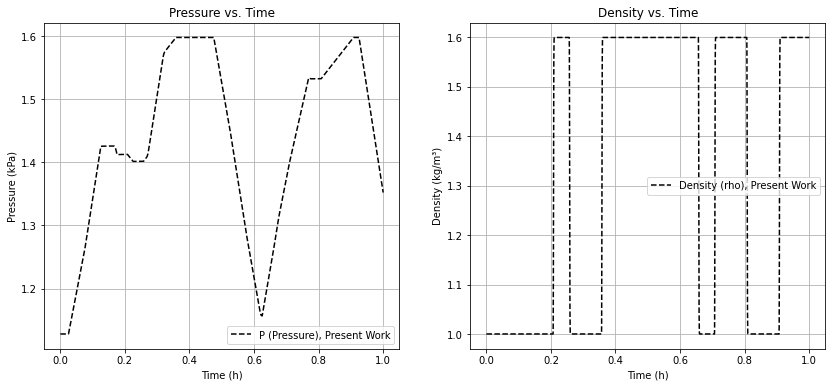

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# Plot Pressure data

axs[0].plot(np.array(plot_time)/3600, np.array(P_inlet_data), '--', label="P (Pressure), Present Work", color='black')
axs[0].set_xlabel("Time (h)")
axs[0].set_ylabel("Pressure (kPa)")
axs[0].set_title("Pressure vs. Time")
axs[0].legend()
# axs[0].set_xlim([0.2, 1])
axs[0].grid(True)

# Plot Density data
axs[1].plot(np.array(plot_time)/3600, np.array(rho_outlet_data), '--', label="Density (rho), Present Work", color='black')
axs[1].set_xlabel("Time (h)")
axs[1].set_ylabel("Density (kg/m³)")
axs[1].set_title("Density vs. Time")
axs[1].legend()
axs[1].grid(True)
plt.show()

In [31]:
U_final

2.090061836027763